# Part B: Bagging & Boosting

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve)

In [2]:
X_train = joblib.load("X_train.pkl")
X_test  = joblib.load("X_test.pkl")
y_train = joblib.load("y_train.pkl")
y_test  = joblib.load("y_test.pkl")

Random Forest

In [3]:
param_grid = {
    'n_estimators': [50,100,200],'max_depth':[None,5,10]}

In [4]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
gs = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("Best CV F1:", round(gs.best_score_, 4))

Best params: {'max_depth': 5, 'n_estimators': 200}
Best CV F1: 0.7895


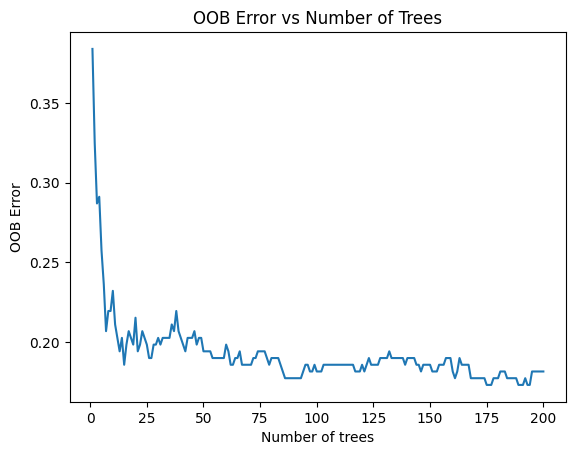

In [5]:
oob_errors = []
for n in range(1, 201):
    m = RandomForestClassifier(n_estimators=n, oob_score=True,
                               random_state=42, class_weight='balanced')
    m.fit(X_train, y_train)
    oob_errors.append(1 - m.oob_score_)

plt.plot(range(1, 201), oob_errors)
plt.xlabel("Number of trees")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Number of Trees")
plt.show()

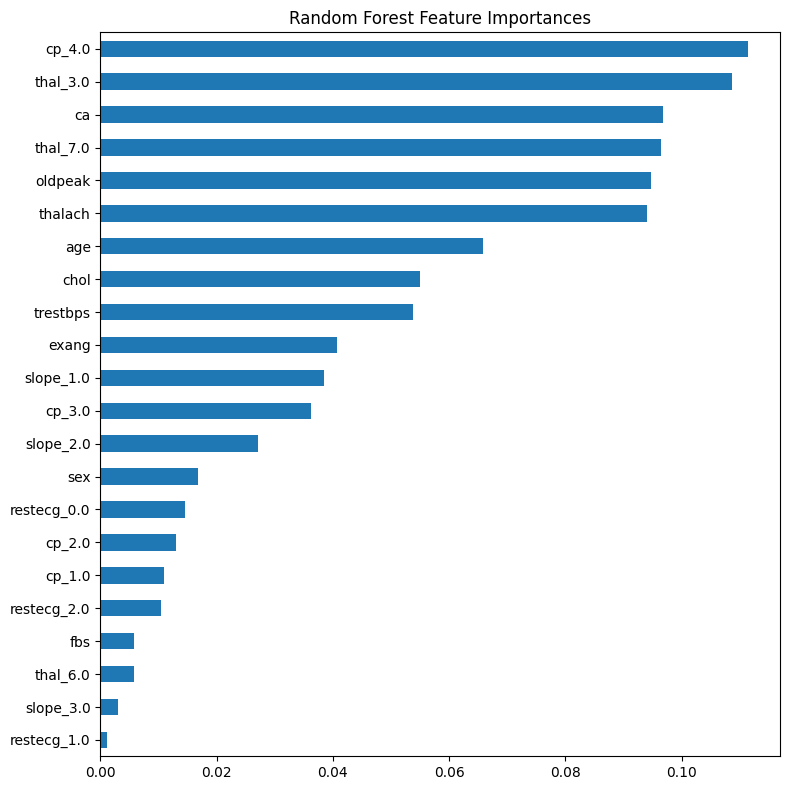

Top 5 features:
cp_4.0      0.111327
thal_3.0    0.108700
ca          0.096759
thal_7.0    0.096380
oldpeak     0.094654
dtype: float64


In [6]:
best_rf = gs.best_estimator_
importances = pd.Series(best_rf.feature_importances_,index=X_train.columns).sort_values()
importances.plot(kind='barh', figsize=(8, 8))
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()
print("Top 5 features:")
print(importances.sort_values(ascending=False).head(5))

In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

AUC-ROC: 0.933


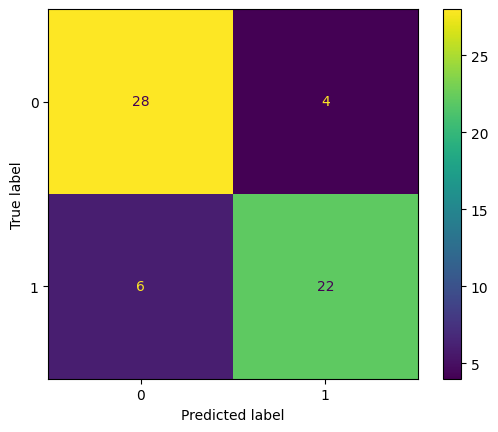

False Negatives: 6
False Positives: 4
True Positives: 22
True Negatives: 28


In [10]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_rf), 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print("False Negatives:", fn)
print("False Positives:", fp)
print("True Positives:", tp)
print("True Negatives:", tn)

##Gradient Boosting

##XGBoost


In [11]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth':     [3, 5, 7]
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42,
                    use_label_encoder=False)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
gs_xgb.fit(X_train, y_train)

print("Best params:", gs_xgb.best_params_)
print("Best CV F1:", round(gs_xgb.best_score_, 4))

Best params: {'learning_rate': 0.3, 'max_depth': 5}
Best CV F1: 0.7897


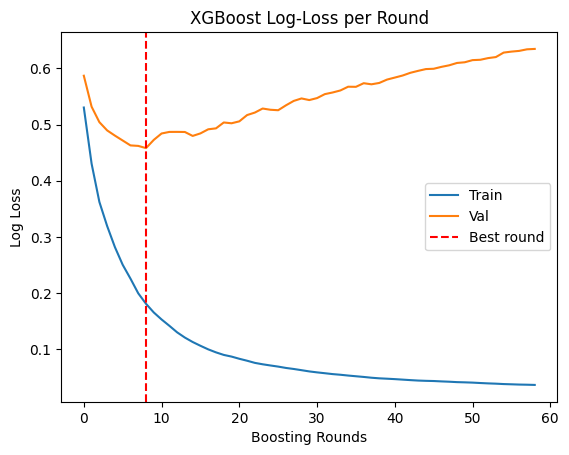

In [15]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,test_size=0.2, random_state=42)

best_xgb = XGBClassifier(
    **gs_xgb.best_params_,
    n_estimators=500,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=50
)
best_xgb.fit(X_tr, y_tr,eval_set=[(X_tr, y_tr), (X_val, y_val)],verbose=False)

results = best_xgb.evals_result()
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Val')
plt.axvline(x=best_xgb.best_iteration, color='red',
            linestyle='--', label='Best round')

plt.title("XGBoost Log-Loss per Round")
plt.xlabel("Boosting Rounds")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

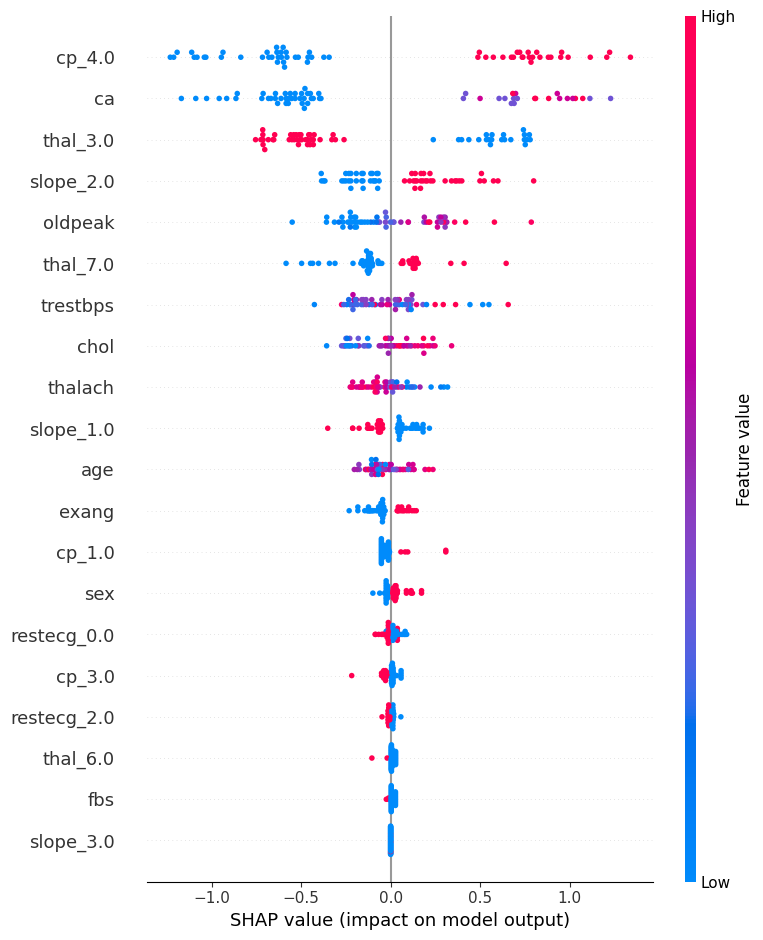

In [13]:
import shap

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=True)

              precision    recall  f1-score   support

           0       0.81      0.94      0.87        32
           1       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60

AUC-ROC: 0.9247


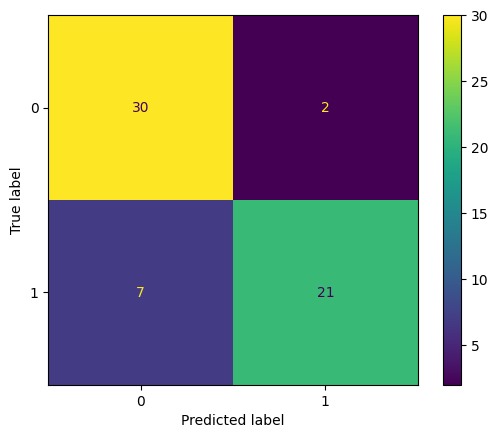

In [14]:
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_xgb), 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.show()

##Ensemble Comparison &amp; ROC

In [16]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb  = nb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_nb))
print("AUC:", round(roc_auc_score(y_test, y_prob_nb), 4))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86        32
           1       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

AUC: 0.9141


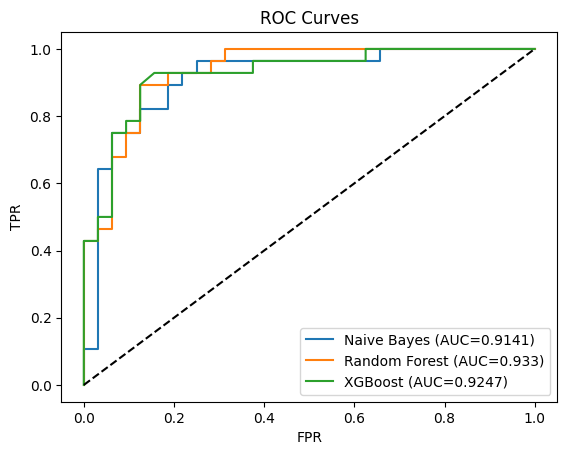

In [17]:
classifiers = [
    ("Naive Bayes",    y_prob_nb),
    ("Random Forest",  y_prob_rf),
    ("XGBoost",        y_prob_xgb)
]

for name, y_prob in classifiers:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = round(roc_auc_score(y_test, y_prob), 4)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [18]:
joblib.dump(best_rf,  "best_rf.pkl")
joblib.dump(best_xgb, "best_xgb.pkl")
print("Models saved.")

Models saved.


In [22]:

import time

results_table = []

def add_results(name, y_true, y_pred, y_prob, train_time):
    results_table.append({
        "Classifier": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average='macro'), 4),
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "Recall (Disease)": round(recall_score(y_true, y_pred), 4),
        "Train Time (s)": round(train_time, 4)
    })


start = time.time()
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
rf_time = time.time() - start

add_results("Random Forest", y_test, y_pred_rf, y_prob_rf, rf_time)


start = time.time()
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
xgb_time = time.time() - start

add_results("XGBoost", y_test, y_pred_xgb, y_prob_xgb, xgb_time)


start = time.time()
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]
nb_time = time.time() - start

add_results("Naive Bayes", y_test, y_pred_nb, y_prob_nb, nb_time)

df_results = pd.DataFrame(results_table)
print(df_results)





      Classifier  Accuracy  Macro F1  AUC-ROC  Recall (Disease)  Train Time (s)
0  Random Forest    0.8333    0.8316   0.9330            0.7857          0.0642
1        XGBoost    0.8500    0.8465   0.9247            0.7500          0.0102
2    Naive Bayes    0.8500    0.8490   0.9141            0.8214          0.0048
